# E-Commerce Sales Performance — Exploratory Data Analysis

**Goal:** understand the e-commerce sales dataset, assess its quality, and surface early insights about sales performance.

**Dataset:** [E-Commerce Sales Performance Analysis (Kaggle)](https://www.kaggle.com/datasets/srisyra02/e-commerce-sales-performance-analysis) — 5,000 orders across product categories, regions, and payment methods.

Each step below is a single cell so the analysis reads top-to-bottom as a clear, reproducible narrative.

## 1. Setup

Import the libraries and the project's helper functions, and set a consistent plot style.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataanalyst.data import fetch_dataset, load_raw, save_processed

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Get the data

`fetch_dataset()` downloads the Kaggle dataset (via `kagglehub`) into `data/raw/`.
It's safe to re-run — files already present are reused, nothing is re-downloaded.

> Requires Kaggle credentials at `~/.kaggle/kaggle.json` (or `KAGGLE_USERNAME` / `KAGGLE_KEY`).

In [2]:
files = fetch_dataset()
files

[WindowsPath('D:/Work/self-project/dataAnalyst/data/raw/E-Commerce Sales Analytics.csv')]

In [3]:
df = load_raw("E-Commerce Sales Analytics.csv")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


## 3. Shape and structure

How many rows and columns, and what is the type of each column?

In [4]:
# Rows and columns
df.shape

(5000, 12)

In [5]:
# Column names, non-null counts, and dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 593.2 KB


## 4. Summary statistics

Distribution of the numeric columns, then a look at the categorical columns.

In [6]:
# Numeric columns
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [7]:
# Categorical columns
df.describe(include="object")

,order_date,product_category,region,payment_method
count,5000,5000,5000,5000
unique,5000,4,4,3
top,1/1/2022,Electronics,West,Card
freq,1,1777,1289,2270


## 5. Missing values

Count missing values per column, then express them as a percentage to judge severity.

In [8]:
# Count of missing values per column
df.isna().sum().sort_values(ascending=False)

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [9]:
# Missing values as a percentage of rows
(df.isna().mean() * 100).round(2).sort_values(ascending=False)

order_id            0.0
order_date          0.0
customer_id         0.0
product_category    0.0
region              0.0
quantity            0.0
unit_price          0.0
discount            0.0
payment_method      0.0
delivery_days       0.0
customer_rating     0.0
revenue             0.0
dtype: float64

## 6. Duplicate rows

Check for exact duplicate records that could distort the analysis.

In [10]:
df.duplicated().sum()

np.int64(0)

## 7. Clean the data

Work on a copy so the raw load stays untouched. Parse `order_date` to a real
datetime and drop exact duplicates, then derive a `month` column for trend analysis.

In [11]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean["order_date"] = pd.to_datetime(df_clean["order_date"], format="%m/%d/%Y")
df_clean["month"] = df_clean["order_date"].dt.to_period("M").dt.to_timestamp()
df_clean.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category               str
region                         str
quantity                     int64
unit_price                 float64
discount                   float64
payment_method                 str
delivery_days                int64
customer_rating            float64
revenue                    float64
month               datetime64[us]
dtype: object

## 8. Sales performance analysis

The core of the project — answering business questions one at a time.

### 8.1 How does revenue trend over time?

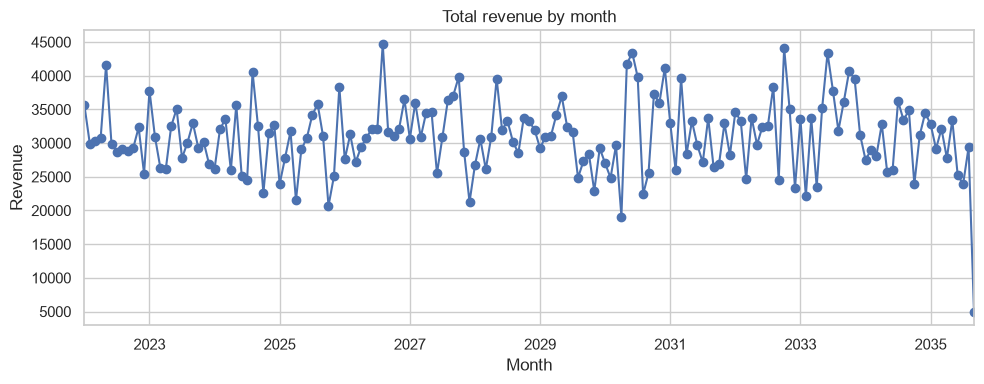

In [12]:
monthly_revenue = df_clean.groupby("month")["revenue"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_revenue.plot(marker="o", ax=ax)
ax.set_title("Total revenue by month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

### 8.2 Which product categories drive the most revenue?

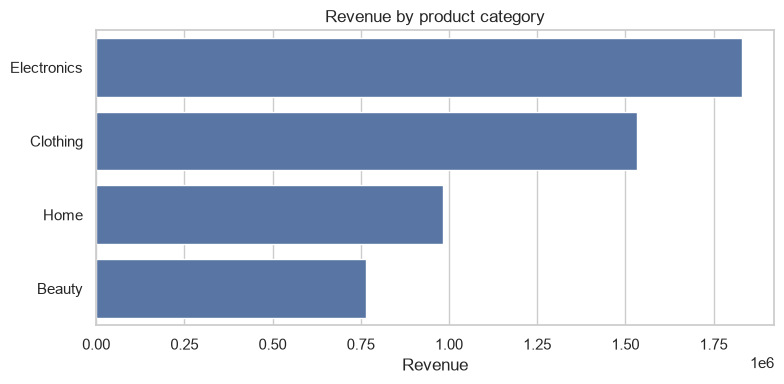

In [13]:
revenue_by_category = (
    df_clean.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, ax=ax)
ax.set_title("Revenue by product category")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 8.3 How does revenue break down by region?

In [14]:
revenue_by_region = (
    df_clean.groupby("region")["revenue"].sum().sort_values(ascending=False)
)
revenue_by_region

region
West     1345582.16
North    1281508.45
South    1246640.90
East     1236044.23
Name: revenue, dtype: float64

### 8.4 Which payment methods are most used?

In [15]:
df_clean["payment_method"].value_counts()

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

### 8.5 How do the numeric measures relate to each other?

A correlation heatmap highlights which measures move together (e.g. quantity,
unit price, discount, and revenue).

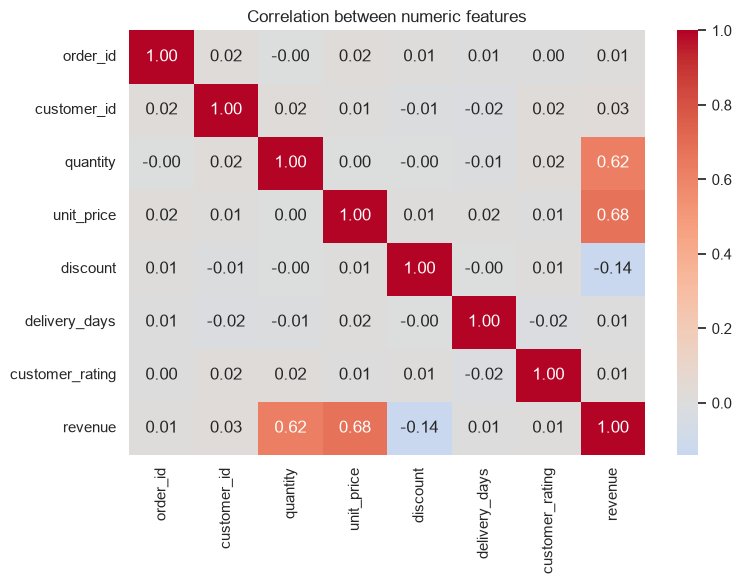

In [16]:
numeric = df_clean.select_dtypes("number")
corr = numeric.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric features")
plt.tight_layout()
plt.show()

## 9. Save the cleaned dataset

Persist the cleaned data to `data/processed/` (Parquet preserves dtypes) so the
next notebook can start from a trusted, ready-to-analyze table.

In [17]:
save_processed(df_clean, "ecommerce_clean.parquet")

WindowsPath('D:/Work/self-project/dataAnalyst/data/processed/ecommerce_clean.parquet')

## Key takeaways

_Fill these in after running the analysis — a short, plain-English summary of what
the charts show is what makes this read like a portfolio piece:_

- Revenue trend: …
- Top categories / regions: …
- Notable relationships (discount vs revenue, delivery vs rating): …

**Next:** deeper analysis (e.g. customer segments, discount impact on margin) in `02_sales_analysis.ipynb`.